Power analysis for the effect size of the birth year coefficient

In [19]:
import statsmodels.formula.api as smf
import pandas as pd          
import matplotlib.pyplot as plt 
import numpy as np
from tqdm import tqdm

In [20]:
combined_df = pd.read_pickle("/home/gaia/Projects/legacy_data/legacy_pipe/data/processed/combined_df_with_weights_per_window.pkl")

In [21]:
min_age = 25
max_age = 30

# volumes df
volumes = combined_df[(combined_df['age_in_years'] >= min_age) & (combined_df['age_in_years'] < max_age)]

# metadata df
# remove duplicates based on subject_id
metadata = volumes.drop_duplicates(subset=['subject_id'])
print(f"shape of {min_age} - {max_age} years old metadata after removing duplicates: {metadata.shape}")

# type of values in the "age_at_scan" column
print(volumes['age_in_years'].dtype)

# 1. Convert the column to numeric (floats)
volumes['age_in_years'] = pd.to_numeric(volumes['age_in_years'], errors='coerce')

shape of 25 - 30 years old metadata after removing duplicates: (1082, 29)
float64


In [22]:
list_of_rois = list([421, 422, 448, 449])

# # all rois 1 to 454
# list_of_rois = list(range(1, 455))


In [23]:
n_list = [25, 33, 50, 70, 100, 135, 175, 225]
reps = 100  # Number of random samplings per N
simulation_results = []

In [25]:
# 2. Run Simulation
for roi in tqdm(list_of_rois):
    print(f"Starting simulation for ROI {roi}...")
    
    # Storage for THIS specific ROI's iterations
    roi_simulation_results = []
    
    # Filter for the specific ROI first to speed up sampling
    df_sim = volumes[volumes['region_label'] == roi].copy()
    
    # Define age range for the title
    min_age = int(df_sim['age_in_years'].min())
    max_age = int(df_sim['age_in_years'].max())

    for n in n_list:
        for r in range(reps):
            try:
                # Sample n scans randomly
                sample_df = df_sim.sample(n=n, replace=False)
            
                # Fit the OLS model
                model = smf.wls(
                    'volume_mm3 ~ birth_year + C(sex) + tiv + age_in_years',
                    data=sample_df,
                    weights=sample_df['ps_weight']
                ).fit()
                
                roi_simulation_results.append({
                    'sample_size': n,
                    'iteration': r,
                    'coef': model.params['birth_year'],
                    'p_val': model.pvalues['birth_year']
                })
            except Exception as e:
                continue

    # Create DataFrame for current ROI
    sim_df = pd.DataFrame(roi_simulation_results)
    
    if sim_df.empty:
        print(f"No results for ROI {roi}, skipping plot.")
        continue

    # 3. Calculate Percentiles for THIS ROI
    stats = sim_df.groupby('sample_size')['coef'].agg([
        'mean',
        lambda x: np.percentile(x, 0.5),   # 99% Lower
        lambda x: np.percentile(x, 99.5),  # 99% Upper
        lambda x: np.percentile(x, 2.5),   # 95% Lower
        lambda x: np.percentile(x, 97.5)   # 95% Upper
    ]).reset_index()

    stats.columns = ['sample_size', 'mean', 'low_99', 'high_99', 'low_95', 'high_95']

    # --- STABILITY LOGIC ---
    # Find all sample sizes where the CI includes zero (the product is <= 0)
    failed_95 = stats[stats['low_95'] * stats['high_95'] <= 0]['sample_size']
    failed_99 = stats[stats['low_99'] * stats['high_99'] <= 0]['sample_size']

    # The last 'failure' defines the boundary. If no failures, use -1.
    last_fail_95 = failed_95.max() if not failed_95.empty else -1
    last_fail_99 = failed_99.max() if not failed_99.empty else -1

    # Stable N is the smallest n in our list that is GREATER than the last failure
    stable_95 = stats[stats['sample_size'] > last_fail_95]['sample_size'].min()
    stable_99 = stats[stats['sample_size'] > last_fail_99]['sample_size'].min()

    simulation_results.append({
        'roi': roi,
        'mean_coef': stats['mean'].iloc[-1], # Using the mean from the largest sample for accuracy
        'first_sample_size_95': stable_95,
        'first_sample_size_99': stable_99
    })
    
    # # 4. Create the Funnel Plot for THIS ROI
    # plt.figure(figsize=(10, 6))

    # # --- Shading Layers ---
    # plt.fill_between(stats['sample_size'], stats['low_99'], stats['high_99'], 
    #                  color='forestgreen', alpha=0.1, label='99% CI')
    # plt.fill_between(stats['sample_size'], stats['low_95'], stats['high_95'], 
    #                  color='forestgreen', alpha=0.2, label='95% CI')

    # # --- Border Lines ---
    # plt.plot(stats['sample_size'], stats['low_99'], color='gray', linestyle='--', lw=0.8, alpha=0.4)
    # plt.plot(stats['sample_size'], stats['high_99'], color='gray', linestyle='--', lw=0.8, alpha=0.4)

    # # --- Central Trend ---
    # plt.plot(stats['sample_size'], stats['mean'], color='forestgreen', lw=2, label='Mean Coef')

    # # Formatting
    # plt.xscale('log')
    # plt.xticks(n_list, labels=[str(x) for x in n_list])
    # plt.axhline(0, color='black', lw=1)
    # plt.xlabel('Sample size')
    # plt.ylabel('Birth Year Coefficient (Effect Size)')
    # plt.legend()
    # plt.title(f'Sample Size Stability For ROI {roi}, {min_age}-{max_age} years old')

    # # Show plot for this ROI
    # plt.tight_layout()
    # plt.show()

  0%|          | 0/4 [00:00<?, ?it/s]

Starting simulation for ROI 421...


 25%|██▌       | 1/4 [00:04<00:12,  4.20s/it]

Starting simulation for ROI 422...


 50%|█████     | 2/4 [00:08<00:08,  4.21s/it]

Starting simulation for ROI 448...


 75%|███████▌  | 3/4 [00:12<00:04,  4.22s/it]

Starting simulation for ROI 449...


100%|██████████| 4/4 [00:16<00:00,  4.21s/it]


In [26]:
# simulation_results to df 
simulation_df = pd.DataFrame(simulation_results)

# # save simulation df for the specific window
# simulation_df.to_csv(f"/home/gaia/Projects/legacy_data/legacy_pipe/data/processed/simulation_results_age_{min_age}_{max_age}.csv", index=False)

# Analyze the needed sample size over all ROIs 

minimal sample size for 99% CI: 135
minimal sample size for 95% CI: 70


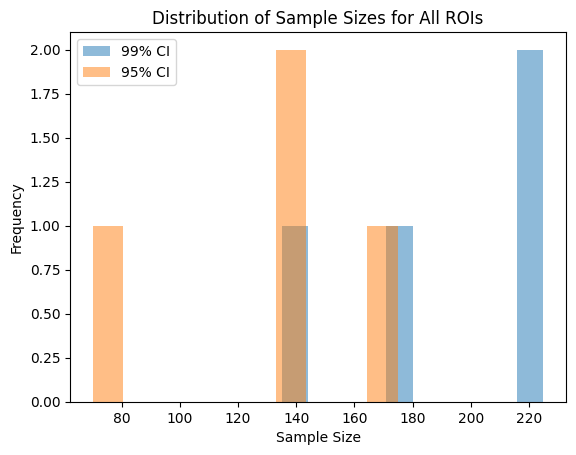

In [27]:


print(f"minimal sample size for 99% CI: {simulation_df['first_sample_size_99'].min()}")
print(f"minimal sample size for 95% CI: {simulation_df['first_sample_size_95'].min()}")

# plot a histogram of first_sample_size_99 and first_sample_size_95 for all rois
plt.hist(simulation_df['first_sample_size_99'], alpha=0.5, label='99% CI')
plt.hist(simulation_df['first_sample_size_95'], alpha=0.5, label='95% CI')
plt.xlabel('Sample Size')
plt.ylabel('Frequency')
plt.title('Distribution of Sample Sizes for All ROIs')
plt.legend()
plt.show()